In [1]:
# ldpc_bsc_gpu.py
import math, numpy as np, torch

# ----------------------------
# 1) Make H in systematic form
# ----------------------------
def make_ldpc_systematic(K: int, R: float = None, M: int = None, col_w: int = 3, seed: int | None = 0):
    """
    Build a binary LDPC parity-check matrix in systematic form H = [A | I_M].
    - K: number of information bits
    - R: desired code rate (0<R<1). If given, M = round(K*(1-R)/R).
    - M: number of parity checks/rows (ignored if R is given)
    - col_w: column weight for A (regular construction, typical 3 or 4)
    Returns: H (np.uint8) of shape (M, K+M)
    """
    assert K > 0
    if R is not None:
        assert 0 < R < 1, "Rate R must be in (0,1)."
        M = max(1, int(round(K*(1-R)/R)))
    assert isinstance(M, int) and M > 0, "Provide a positive M or valid R."

    rng = np.random.default_rng(seed)
    # Build A (M x K) with exactly col_w ones per column, distributing across lightest rows
    rows = []
    cols = []
    row_load = np.zeros(M, dtype=int)
    for j in range(K):
        # pick 'col_w' distinct rows, preferring currently light rows
        order = np.argsort(row_load, kind='stable')
        pool = order[:min(M, 2*col_w + 8)]
        sel = rng.choice(pool, size=min(col_w, len(pool)), replace=False)
        rows.extend(sel.tolist())
        cols.extend([j]*len(sel))
        row_load[sel] += 1

    A = np.zeros((M, K), dtype=np.uint8)
    if len(rows) > 0:
        A[rows, cols] ^= 1  # place ones

    # ensure no all-zero rows
    zrows = np.where(A.sum(axis=1) == 0)[0]
    for r in zrows:
        j = rng.integers(0, K)
        A[r, j] ^= 1

    # form H = [A | I]
    H = np.zeros((M, K+M), dtype=np.uint8)
    H[:, :K] = A
    H[:, K:] = np.eye(M, dtype=np.uint8)
    return H

# ----------------------------
# 2) Encoder/Simulator/Decoder
# ----------------------------
def simulate_ldpc_bsc_fixedllr(H: np.ndarray, p: float, L0: float = 10.0,
                               nframes: int = 200, max_iter: int = 50,
                               use_gpu: bool = True):
    """
    LDPC over BSC(p) with fixed-magnitude LLRs (±L0) and a bit-flip decoder.
    H: np.uint8 (M x N) with right block = I_M  (systematic)
    p: crossover probability (pre-decoder BER)
    Returns: dict with BLER, BER, etc.
    """
    assert H.dtype == np.uint8 and H.ndim == 2
    M, N = H.shape
    K = N - M
    assert np.all(H[:, K:] == np.eye(M, dtype=np.uint8)), "H must be [A|I]."

    device = 'cuda' if (use_gpu and torch.cuda.is_available()) else 'cpu'
    H_t = torch.tensor(H, dtype=torch.float32, device=device)  # 0/1 matrix
    A_t = H_t[:, :K]
    I_M = H_t[:, K:]  # not used directly but available
    n_block_err = 0
    n_bit_err = 0

    for _ in range(nframes):
        # ---- Encode (systematic): p_bits = (A @ u) mod 2; c = [u; p_bits]
        u = torch.randint(0, 2, (K,), device=device, dtype=torch.float32)
        p_bits = (A_t @ u) % 2.0
        c = torch.cat([u, p_bits])  # length N, 0/1 floats

        # ---- BSC channel and fixed LLRs
        flips = (torch.rand(N, device=device) < p).float()
        r = (c + flips) % 2.0
        llr = L0 * (1.0 - 2.0 * r)   # 0 -> +L0, 1 -> -L0  (we keep llr for possible soft use)

        # ---- Bit-flip (Gallager-B) hard-decision decoder
        chat = (llr < 0).float()     # initial hard decision
        for _it in range(max_iter):
            synd = (H_t @ chat) % 2.0                  # M
            if synd.sum() == 0:
                break
            uns = H_t.t() @ synd                       # N, number of unsatisfied checks per bit
            thr = uns.max()
            flip_mask = (uns == thr) & (thr > 0)
            chat = (chat + flip_mask.float()) % 2.0    # flip those bits

        uhat = chat[:K]
        bit_err = (uhat != u).sum().item()
        n_bit_err += int(bit_err)
        n_block_err += int(bit_err > 0)

    return {
        'BLER': n_block_err / nframes,
        'BER' : n_bit_err / (nframes * K),
        'frames': nframes,
        'K': K, 'M': M, 'N': N, 'R': K/N,
        'device': device
    }

# ----------------------------
# 3) Example use cases
# ----------------------------
if __name__ == "__main__":

    K, M = 256, 256*3*19-256          # N=1500, R=0.2 (same rate via explicit M)
    H2 = make_ldpc_systematic(K, M=M, col_w=4, seed=1)
    res2 = simulate_ldpc_bsc_fixedllr(H2, p=0.30, L0=10, nframes=10, max_iter=100, use_gpu=True)
    print("Example B:", res2)


Example B: {'BLER': 0.9, 'BER': 0.015234375, 'frames': 10, 'K': 256, 'M': 14336, 'N': 14592, 'R': 0.017543859649122806, 'device': 'cuda'}


# Simulating the traditional

In [2]:
import pickle

file_path = "../MongoDB_Analyzer/df0.0_proposed.pkl"

# pickle loads
with open(file_path, 'rb') as file:
    data = pickle.load(file)

bin_size = 0.5  # Example bin size
data['SNR_bin'] = (data['SNR'] // bin_size) * bin_size
average_ber_per_bin = data.groupby('SNR_bin')['BER_msg'].mean()
print(average_ber_per_bin)


K, M = 256, 256       # N=1500, R=0.2 (same rate via explicit M)
print(K, M)
H2 = make_ldpc_systematic(K, M=M, col_w=4, seed=1)

ldpc_error_rate = {}
for snr_bin, ber in average_ber_per_bin.items():
    p = ber  # Use BER as the crossover probability
    result = simulate_ldpc_bsc_fixedllr(H2, p=p, L0=10, nframes=200, max_iter=20, use_gpu=True)
    print(f"SNR bin: {snr_bin}, Simulated BLER: {result['BLER']}")
    ldpc_error_rate[snr_bin] = result['BLER']

print(ldpc_error_rate)

SNR_bin
0.0    0.440662
0.5    0.334241
1.0    0.287767
1.5    0.207550
2.0    0.121802
2.5    0.074380
3.0    0.061942
3.5    0.033019
4.0    0.017343
4.5    0.014065
5.0    0.005894
5.5    0.003002
6.0    0.001389
6.5    0.000789
7.0    0.000320
7.5    0.000104
8.0    0.000050
Name: BER_msg, dtype: float64
256 256
SNR bin: 0.0, Simulated BLER: 1.0
SNR bin: 0.5, Simulated BLER: 1.0
SNR bin: 1.0, Simulated BLER: 1.0
SNR bin: 1.5, Simulated BLER: 1.0
SNR bin: 2.0, Simulated BLER: 1.0
SNR bin: 2.5, Simulated BLER: 0.995
SNR bin: 3.0, Simulated BLER: 0.965
SNR bin: 3.5, Simulated BLER: 0.825
SNR bin: 4.0, Simulated BLER: 0.515
SNR bin: 4.5, Simulated BLER: 0.395
SNR bin: 5.0, Simulated BLER: 0.145
SNR bin: 5.5, Simulated BLER: 0.03
SNR bin: 6.0, Simulated BLER: 0.035
SNR bin: 6.5, Simulated BLER: 0.015
SNR bin: 7.0, Simulated BLER: 0.005
SNR bin: 7.5, Simulated BLER: 0.005
SNR bin: 8.0, Simulated BLER: 0.0
{0.0: 1.0, 0.5: 1.0, 1.0: 1.0, 1.5: 1.0, 2.0: 1.0, 2.5: 0.995, 3.0: 0.965, 3.5: 0.8

In [ ]:
# Save the ldpc_error_rate dictionary to a pickle file
output_file_path = "df0.0_ldpc_bler.pkl"

with open(output_file_path, 'wb') as output_file:
    pickle.dump(ldpc_error_rate, output_file)

print(f"LDPC BLER data saved to {output_file_path}")

LDPC BLER data saved to df0.0_ldpc_bler.pkl


In [32]:
import os
import glob

# Directory containing the .pkl files
directory_path = "../MongoDB_Analyzer/"
output_directory = "./"  # Directory to save the output files

# Get all .pkl files in the directory
pkl_files = glob.glob(os.path.join(directory_path, "*.pkl"))

K, M = int((256*3*19 - 512)/2), int( (256*3*19 - 512)/2 + 512 )           
H2 = make_ldpc_systematic(K, M=M, col_w=4, seed=1)

for file_path in pkl_files:
    
    # Load the .pkl file
    with open(file_path, 'rb') as file:
        data = pickle.load(file)

    # Process the data
    bin_size = 0.5  # Example bin size
    try:
        data['SNR_bin'] = (data['SNR'] // bin_size) * bin_size
    except:
        continue
    average_ber_per_bin = data.groupby('SNR_bin')['BER_msg'].mean()

    # Generate LDPC error rates
    ldpc_error_rate = {}
    for snr_bin, ber in average_ber_per_bin.items():
        p = ber  # Use BER as the crossover probability
        result = simulate_ldpc_bsc_fixedllr(H2, p=p, L0=10, nframes=200, max_iter=20, use_gpu=True)
        ldpc_error_rate[snr_bin] = result['BLER']
        print(f"Processed file: {file_path}, LDPC BLER: {ldpc_error_rate[snr_bin]} for SNR bin: {snr_bin}, BER: {ber}")

    # Save the results to a new .pkl file
    output_file_name = os.path.basename(file_path).replace(".pkl", "_ldpc_bler.pkl")
    output_file_path = os.path.join(output_directory, output_file_name)

    with open(output_file_path, 'wb') as output_file:
        pickle.dump(ldpc_error_rate, output_file)

    print(f"LDPC BLER data saved to {output_file_path}")

Processed file: ../MongoDB_Analyzer/df0.3_proposed.pkl, LDPC BLER: 1.0 for SNR bin: 0.5, BER: 0.41707785087719296
Processed file: ../MongoDB_Analyzer/df0.3_proposed.pkl, LDPC BLER: 1.0 for SNR bin: 1.0, BER: 0.353850371120108
Processed file: ../MongoDB_Analyzer/df0.3_proposed.pkl, LDPC BLER: 1.0 for SNR bin: 1.5, BER: 0.30478766025641024
Processed file: ../MongoDB_Analyzer/df0.3_proposed.pkl, LDPC BLER: 1.0 for SNR bin: 2.0, BER: 0.2583093475877193
Processed file: ../MongoDB_Analyzer/df0.3_proposed.pkl, LDPC BLER: 1.0 for SNR bin: 2.5, BER: 0.21780199195906433
Processed file: ../MongoDB_Analyzer/df0.3_proposed.pkl, LDPC BLER: 1.0 for SNR bin: 3.0, BER: 0.19266645346003897
Processed file: ../MongoDB_Analyzer/df0.3_proposed.pkl, LDPC BLER: 1.0 for SNR bin: 3.5, BER: 0.16453536184210524
Processed file: ../MongoDB_Analyzer/df0.3_proposed.pkl, LDPC BLER: 1.0 for SNR bin: 4.0, BER: 0.15877764071637426
Processed file: ../MongoDB_Analyzer/df0.3_proposed.pkl, LDPC BLER: 1.0 for SNR bin: 4.5, BE

In [4]:
import os
import glob

# Directory containing the .pkl files
directory_path = "../MongoDB_Analyzer/"
output_directory = "./"  # Directory to save the output files

# Get all .pkl files in the directory
pkl_files = glob.glob(os.path.join(directory_path, "*.pkl"))
K, M = int(256), int( 256*3*19 - 256 )           
H2 = make_ldpc_systematic(K, M=M, col_w=4, seed=1)

for file_path in pkl_files:
    
    # Load the .pkl file
    with open(file_path, 'rb') as file:
        data = pickle.load(file)

    # Process the data
    bin_size = 0.5  # Example bin size
    try:
        data['SNR_bin'] = (data['SNR'] // bin_size) * bin_size
    except:
        continue
    average_ber_per_bin = data.groupby('SNR_bin')['BER_tag'].mean()

    # Generate LDPC error rates
    ldpc_error_rate = {}
    for snr_bin, ber in average_ber_per_bin.items():
        p = ber  # Use BER as the crossover probability
        result = simulate_ldpc_bsc_fixedllr(H2, p=p, L0=10, nframes=200, max_iter=20, use_gpu=True)
        ldpc_error_rate[snr_bin] = result['BLER']
        print(f"Processed file: {file_path}, LDPC BLER: {ldpc_error_rate[snr_bin]} for SNR bin: {snr_bin}, BER: {ber}")

    # Save the results to a new .pkl file
    output_file_name = os.path.basename(file_path).replace(".pkl", "_ldpc_bler_tag.pkl")
    output_file_path = os.path.join(output_directory, output_file_name)

    with open(output_file_path, 'wb') as output_file:
        pickle.dump(ldpc_error_rate, output_file)

    print(f"LDPC BLER data saved to {output_file_path}")

KeyboardInterrupt: 

['./df0.4_proposed_ldpc_bler_tag.pkl', './df0.3_proposed_ldpc_bler_tag.pkl', './df0.2_proposed_ldpc_bler_tag.pkl', './df0.15_proposed_ldpc_bler_tag.pkl', './df0.35_proposed_ldpc_bler_tag.pkl', './df_trad_ldpc_bler_tag.pkl', './df0.25_proposed_ldpc_bler_tag.pkl', './df0.1_proposed_ldpc_bler_tag.pkl']
./df0.4_proposed_ldpc_bler_tag.pkl
./df0.3_proposed_ldpc_bler_tag.pkl
./df0.2_proposed_ldpc_bler_tag.pkl
./df0.15_proposed_ldpc_bler_tag.pkl
./df0.35_proposed_ldpc_bler_tag.pkl
./df_trad_ldpc_bler_tag.pkl
./df0.25_proposed_ldpc_bler_tag.pkl
./df0.1_proposed_ldpc_bler_tag.pkl
./df0.4_proposed_ldpc_bler_tag.pkl
./df0.3_proposed_ldpc_bler_tag.pkl
./df0.2_proposed_ldpc_bler_tag.pkl
./df0.15_proposed_ldpc_bler_tag.pkl
./df0.35_proposed_ldpc_bler_tag.pkl
./df_trad_ldpc_bler_tag.pkl
./df0.25_proposed_ldpc_bler_tag.pkl
./df0.1_proposed_ldpc_bler_tag.pkl


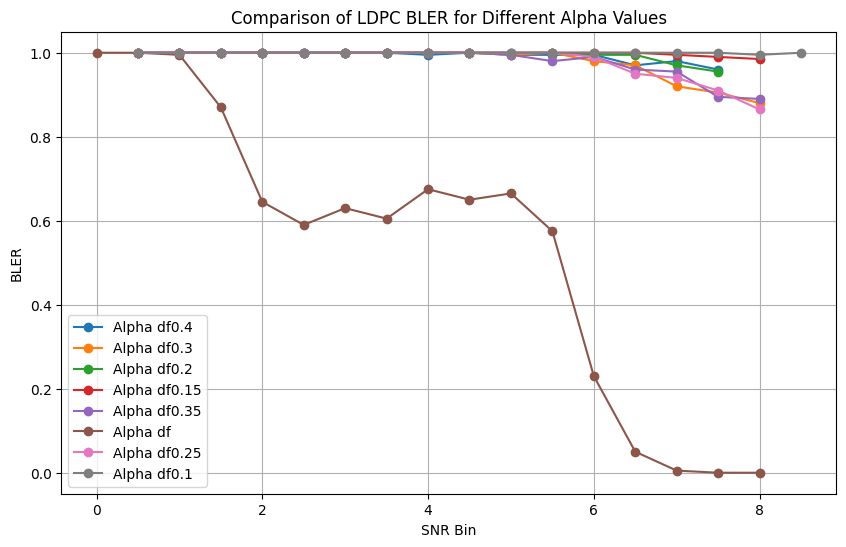

In [19]:
import matplotlib.pyplot as plt

# Initialize a dictionary to store data for plotting
plot_data = {}

# Iterate through the pickle files and load the data
pkl_files = glob.glob(os.path.join(".", "*_ldpc_bler_tag.pkl"))
print(pkl_files)
for file_path in pkl_files:
    if "_ldpc_bler_tag" in file_path:  # Only process files with LDPC BLER data
        print(file_path)

for file_path in pkl_files:
    if "_ldpc_bler_tag.pkl" in file_path:  # Only process files with LDPC BLER data
        print(file_path)
        alpha = file_path.split("_")[0].split("/")[-1]  # Extract alpha from the file name
        with open(file_path, 'rb') as file:
            ldpc_data = pickle.load(file)
        plot_data[alpha] = ldpc_data

# Plot the data
plt.figure(figsize=(10, 6))
for alpha, data in plot_data.items():
    snr_bins = list(data.keys())
    bler_values = list(data.values())
    plt.plot(snr_bins, bler_values, marker='o', label=f"Alpha {alpha}")

plt.xlabel("SNR Bin")
plt.ylabel("BLER")
plt.title("Comparison of LDPC BLER for Different Alpha Values")
plt.legend()
plt.grid(True)
plt.show()